Optimal RBFS Path:
Gateway of India -> Marine Drive -> Haji Ali -> Lower Parel -> Dadar -> Mahim -> Bandra Bandstand

Total Road Distance: 25 km


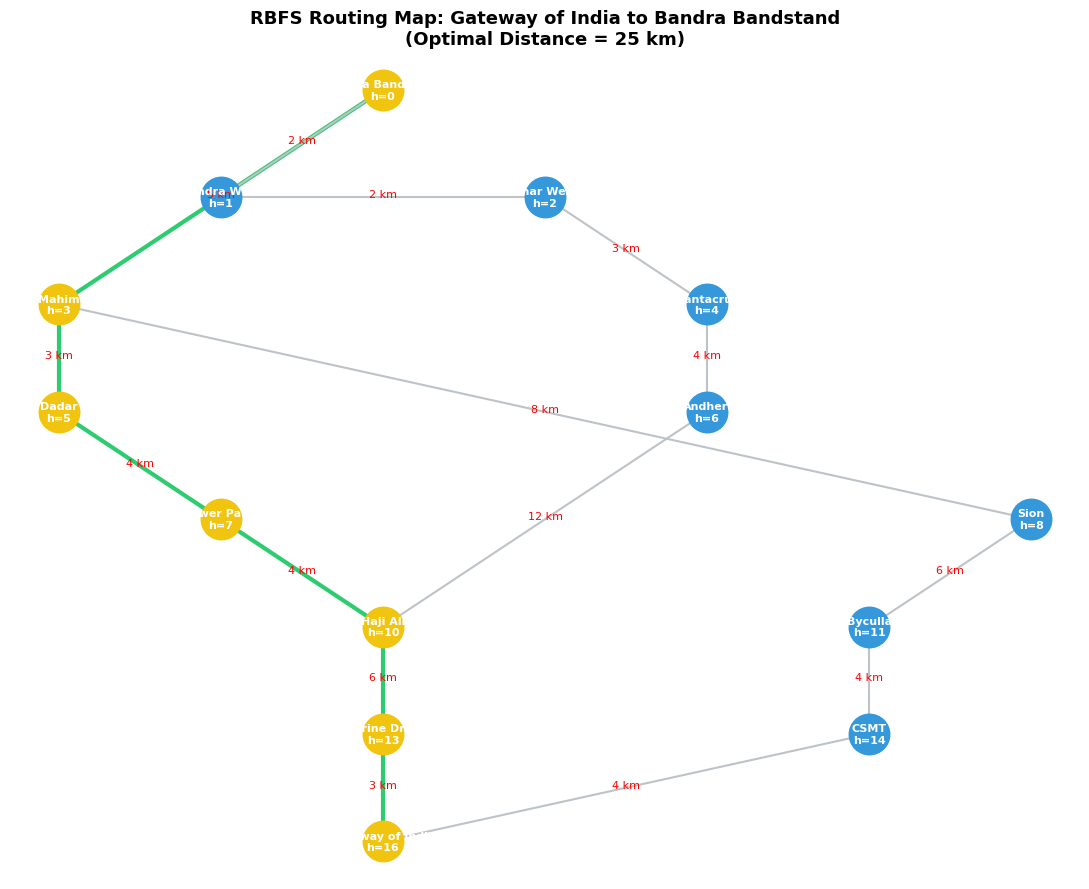

In [1]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. NETWORK DEFINITION
# -------------------------------------------------------------------------

# Road distances g(n)
graph = {

    'Gateway of India': {
        'Marine Drive': 3,
        'CSMT': 4
    },

    'Marine Drive': {
        'Haji Ali': 6
    },

    'CSMT': {
        'Byculla': 4
    },

    'Haji Ali': {
        'Lower Parel': 4,
        'Andheri': 12
    },

    'Byculla': {
        'Sion': 6
    },

    'Lower Parel': {
        'Dadar': 4
    },

    'Andheri': {
        'Santacruz': 4
    },

    'Sion': {
        'Mahim': 8
    },

    'Dadar': {
        'Mahim': 3
    },

    'Santacruz': {
        'Khar West': 3
    },

    'Mahim': {
        'Bandra Bandstand': 5
    },

    'Khar West': {
        'Bandra West': 2
    },

    'Bandra West': {
        'Bandra Bandstand': 2
    },

    'Bandra Bandstand': {}
}

# -------------------------------------------------------------------------
# Straight-line heuristic values h(n)
# Goal = Bandra Bandstand
# -------------------------------------------------------------------------

heuristics = {

    'Gateway of India': 16,
    'Marine Drive': 13,
    'CSMT': 14,
    'Haji Ali': 10,
    'Byculla': 11,
    'Lower Parel': 7,
    'Andheri': 6,
    'Sion': 8,
    'Dadar': 5,
    'Santacruz': 4,
    'Mahim': 3,
    'Khar West': 2,
    'Bandra West': 1,
    'Bandra Bandstand': 0
}

# -------------------------------------------------------------------------
# Coordinates (Only for plotting)
# -------------------------------------------------------------------------

coords = {

    'Gateway of India': (6, 0),

    'Marine Drive': (6, 2),

    'CSMT': (9, 2),

    'Haji Ali': (6, 4),

    'Byculla': (9, 4),

    'Lower Parel': (5, 6),

    'Sion': (10, 6),

    'Dadar': (4, 8),

    'Andheri': (8, 8),

    'Mahim': (4, 10),

    'Santacruz': (8, 10),

    'Khar West': (7, 12),

    'Bandra West': (5, 12),

    'Bandra Bandstand': (6, 14)
}

# -------------------------------------------------------------------------
# 2. RECURSIVE BEST-FIRST SEARCH (RBFS)
# -------------------------------------------------------------------------

def rbfs_search(start, goal):

    success, path, cost, _ = rbfs(
        start,
        goal,
        g=0,
        f_limit=float('inf'),
        path=[start]
    )

    return path, cost


def rbfs(node, goal, g, f_limit, path):

    # Goal reached
    if node == goal:
        return True, path, g, g

    neighbors = graph[node]

    # Dead end
    if not neighbors:
        return False, [], 0, float('inf')

    successors = []

    # Build successor list
    for neighbor, distance in neighbors.items():

        if neighbor not in path:

            next_g = g + distance

            next_f = max(
                next_g + heuristics[neighbor],
                g + heuristics[node]
            )

            successors.append(
                [next_f, neighbor, next_g]
            )

    if not successors:
        return False, [], 0, float('inf')

    while True:

        successors.sort(key=lambda x: x[0])

        best = successors[0]

        # If best exceeds current limit,
        # backtrack.
        if best[0] > f_limit:
            return False, [], 0, best[0]

        if len(successors) > 1:
            alternative = successors[1][0]
        else:
            alternative = float('inf')

        success, result_path, total_g, returned_f = rbfs(

            best[1],
            goal,
            best[2],
            min(f_limit, alternative),
            path + [best[1]]

        )

        best[0] = returned_f

        if success:
            return True, result_path, total_g, returned_f

        # -------------------------------------------------------------------------
# 3. RUN THE ALGORITHM
# -------------------------------------------------------------------------

path, total_dist = rbfs_search(
    'Gateway of India',
    'Bandra Bandstand'
)

print("Optimal RBFS Path:")
print(" -> ".join(path))
print(f"\nTotal Road Distance: {total_dist} km")

# -------------------------------------------------------------------------
# 4. GRAPH PLOTTING
# -------------------------------------------------------------------------

plt.figure(figsize=(11, 9))

# Draw all road connections
for node, neighbors in graph.items():

    x1, y1 = coords[node]

    for neighbor, dist in neighbors.items():

        x2, y2 = coords[neighbor]

        is_path = (
            node in path and
            neighbor in path and
            path.index(neighbor) == path.index(node) + 1
        )

        if is_path:
            color = '#2ecc71'
            width = 3
        else:
            color = '#bdc3c7'
            width = 1.5

        plt.plot(
            [x1, x2],
            [y1, y2],
            color=color,
            linewidth=width,
            zorder=1
        )

        plt.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            f"{dist} km",
            color='red',
            fontsize=8,
            ha='center'
        )

# Draw nodes
for node, (x, y) in coords.items():

    if node in path:
        color = '#f1c40f'
    else:
        color = '#3498db'

    plt.scatter(
        x,
        y,
        color=color,
        s=850,
        zorder=2
    )

    plt.text(
        x,
        y,
        f"{node}\nh={heuristics[node]}",
        ha='center',
        va='center',
        color='white',
        fontsize=8,
        fontweight='bold'
    )

plt.title(
    f"RBFS Routing Map: Gateway of India to Bandra Bandstand\n"
    f"(Optimal Distance = {total_dist} km)",
    fontsize=13,
    fontweight='bold'
)

plt.axis('off')
plt.tight_layout()
plt.show()